<div style="background: linear-gradient(135deg, #1e293b 0%, #0f172a 100%); padding: 30px; border-radius: 8px; margin-bottom: 25px; box-shadow: 0 4px 6px -1px rgba(0, 0, 0, 0.1);">
    <h1 style="color: #f8fafc; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; font-weight: 700; margin: 0; font-size: 2.2em; letter-spacing: -0.5px;">  Modelo de Importancia Global de Factores 🌍
</h1>
    <p style="color: #94a3b8; font-family: 'Segoe UI', sans-serif; margin: 8px 0 0 0; font-size: 1.1em;">Global Feature Importance (XAI)</p>
    
</div>

# Vision General

###  El impacto  de `HOMEPOS` en el rendimiento matemático Global

El mmodelo de regresión basado en árboles de decisión (*Random Forest*), destaca la importancia absoluta del índice **`HOMEPOS`** (*Home Possessions*), el cual permite definir la brecha de rendimiento en matemáticas entre los distintos sistemas educativos internacionales.

* **Naturaleza del Índice:** `HOMEPOS` es un índice estandarizado desarrollado por la OCDE mediante modelos de Teoría de Respuesta al Ítem (IRT). Su propósito es cuantificar y hacer comparables a escala global las condiciones materiales, digitales y culturales del entorno socio-familiar del estudiante.

* **Composición :** Este indicador integra diferentes elementos que pueden agruparse en cuatro ejes principales:
  1. **Espacio físico y estudio:** Disponibilidad de un escritorio propio y un lugar tranquilo para el estudio.
  2. **Infraestructura digital:** Acceso funcional a ordenadores y conectividad a internet en el hogar.
  3. **Riqueza material básica:** Bienes, comodidades e infraestructura habitacional de la familia.
  4. **Entorno cultural y letrado:** Presencia de herramientas de consulta, diccionarios y, de manera muy significativa, el volumen de libros disponibles en casa.

* **Explicación y Conclusiones:** Debido a la alta multicolinealidad existente entre los factores socioeconómicos en PISA (`ESCS`, `HISEI`, `PAREDINT`), el algoritmo selecciona a `HOMEPOS` como la *feature* óptima y más eficiente para capturar la ventaja material y cultural.

Se demostraría así que **la brecha material, digital y cultural del hogar funciona como el vector estructural definitivo** que discrimina y explica con mayor contundencia el éxito o el rezago de las naciones en el rendimiento matemático global.

In [23]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
ruta_datos_procesados ='../../data/processed'

In [4]:
matriz_modelo_pais= os.path.join(ruta_datos_procesados,'pisa22_submuestra_pais_consolidada.parquet')


In [6]:
df_analisis_modelo_pais = pd.read_parquet(matriz_modelo_pais)

In [8]:
df_analisis_modelo_pais.head()

,CNT,media_math_pisa,PAREDINT,HISEI,HOMEPOS,ESCS,BELONG,TEACHSUP,MATHEFF,ANXMAT,STRATIO,PROPMATH,STAFFSHORT,EDUSHORT
0,ALB,368.221720,12.995368,45.751011,-0.839871,-0.708247,0.122006,0.308400,-0.367129,0.139956,13.937516,0.111787,-0.655399,0.098963
1,ARE,431.110477,15.057775,65.236542,-0.200819,0.279370,-0.224651,0.174018,-0.290678,0.182672,14.438646,0.147710,0.066412,-0.278198
2,ARG,377.529029,12.906470,43.960266,-0.874134,-0.771609,-0.199733,0.258542,-0.724162,0.439967,9.147843,0.108352,0.514345,0.606678
3,AUS,487.084254,14.570253,57.972633,0.422583,0.323736,-0.227144,0.123185,-0.281157,0.178700,12.847009,0.163637,0.041028,-0.667685
4,AUT,487.267499,14.081729,51.757549,0.198276,0.031946,0.427076,-0.398491,0.007452,0.078246,10.350581,0.150821,-0.059988,-0.361610


In [9]:
indices_derivados = [
    'PAREDINT', 'HISEI', 'HOMEPOS', 'ESCS',     # Familia
    'BELONG', 'TEACHSUP', 'MATHEFF', 'ANXMAT',  # Alumno
    'STRATIO', 'PROPMATH', 'STAFFSHORT', 'EDUSHORT' # Escuela
]

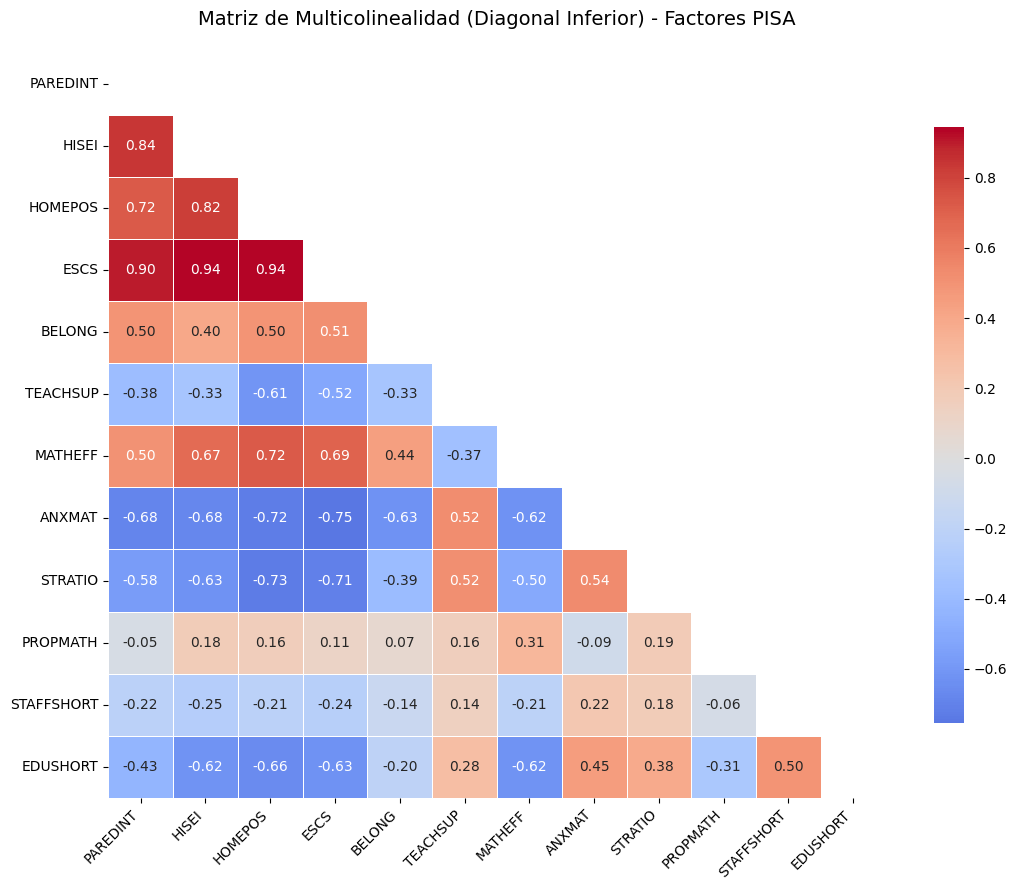

In [35]:

matriz_corr_features = df_analisis_modelo_pais[indices_derivados].corr()

mascara = np.triu(np.ones_like(matriz_corr_features, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))

sns.heatmap(
    matriz_corr_features,
    mask=mascara,          # Oculta la parte superior repetida
    annot=True,            # Muestra los valores numéricos
    fmt=".2f",             # Dos decimales
    cmap="coolwarm",       # Paleta divergente
    center=0,              # Blanco en el cero
    linewidths=0.5,        # Líneas divisorias sutiles
    cbar_kws={"shrink": 0.8},
    ax=ax
)


plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.title("Matriz de Multicolinealidad (Diagonal Inferior) - Factores PISA", fontsize=14, pad=20)

plt.tight_layout()
plt.savefig('../../reports/figures/heatmap_multicolinealidad_pais.png', dpi=300)

In [11]:
X = df_analisis_modelo_pais[indices_derivados]
y = df_analisis_modelo_pais['media_math_pisa']

#Se incializa el arbol de regresion
rf_model = RandomForestRegressor(
    n_estimators=100, 
    max_depth=5,       # Limitamos la profundidad para evitar sobreajuste con pocos países
    random_state=42
)

# Se entrena el modelo
rf_model.fit(X, y)

# Se extraen y ordenan las importancias de cada variable
importancias = pd.Series(rf_model.feature_importances_, index=indices_derivados)
importancias_ordenadas = importancias.sort_values(ascending=False)

In [12]:
# Se muestran los resultados
print("Variables de importancia para el rendimiento en Matemáticas:")

display(importancias_ordenadas.to_frame(name='Importancia_Relativa'))

Variables de importancia para el rendimiento en Matemáticas:


,Importancia_Relativa
HOMEPOS,0.799540
TEACHSUP,0.035094
MATHEFF,0.033931
ESCS,0.030883
EDUSHORT,0.020186
PROPMATH,0.016504
BELONG,0.016431
PAREDINT,0.013868
STRATIO,0.010284
ANXMAT,0.008898


In [21]:
score_r2 = rf_model.score(X, y)
print(f"\nCoeficiente de determinación (R²): {score_r2:.4f}")


Coeficiente de determinación (R²): 0.9398


Dado que HOMEPOS, ESCS y HISEI están fuertemente correlacionadas, el Random Forest selecciona a HOMEPOS como la variable más óptima y concentra en ella la ganancia de información global, enmascarando el peso directo de las demás.

Evaluamos el modelo sin HOMEPOS

In [17]:
indices_sin_homepos = [col for col in indices_derivados if col != 'HOMEPOS']

# 2. Re-definimos X sin esa columna
X_sin_homepos = df_analisis_modelo_pais[indices_sin_homepos]
y = df_analisis_modelo_pais['media_math_pisa']

# 3. Entrenamos de nuevo el Random Forest con los mismos parámetros
rf_model_alt = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model_alt.fit(X_sin_homepos, y)

# 4. Extraemos el nuevo ranking
importancias_alt = pd.Series(rf_model_alt.feature_importances_, index=indices_sin_homepos)
importancias_alt_ordenadas = importancias_alt.sort_values(ascending=False)

print("Importancias sin HOMEPOS")
display(importancias_alt_ordenadas.to_frame(name='Importancia_Relativa_Alt'))

Importancias sin HOMEPOS


,Importancia_Relativa_Alt
ESCS,0.467140
MATHEFF,0.186802
HISEI,0.068892
TEACHSUP,0.065433
STRATIO,0.057643
EDUSHORT,0.048937
PROPMATH,0.035427
BELONG,0.021435
ANXMAT,0.017062
PAREDINT,0.016122


In [19]:
score_r2 = rf_model_alt.score(X_sin_homepos, y)
print(f"\nCoeficiente de determinación (R²): {score_r2:.4f}")


Coeficiente de determinación (R²): 0.9196


HOMEPOS como indicador sintético de la brecha estructural: El hecho de que el bosque de decisión concentre el peso en HOMEPOS demuestra que, a escala macrointernacional, la brecha material y digital entre los sistemas educativos punteros y los rezagados es el mayor factor discriminante del rendimiento en matemáticas